# Monotonic SAR ADC analysis
This ADC simulation tries to model the behaviour of [1] by adding capacitor mismatch and comparator nonidealities.

[1] C.-C. Liu, S.-J. Chang, G.-Y. Huang, and Y.-Z. Lin, “A 10-bit 50-MS/s SAR ADC With a Monotonic Capacitor Switching Procedure,” IEEE Journal of Solid-State Circuits, vol. 45, no. 4, pp. 731–740, Apr. 2010, doi: 10.1109/JSSC.2010.2042254.


In [402]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

plt.style.use('_mpl-gallery')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set1.colors)

In [403]:
def sndr2enob(sndr):
	return (sndr - 1.76)/6.02

def dft(signal, N, Fs):
	fft_output = scipy.fft.fft(signal)
	frequencies = scipy.fft.fftfreq(N, 1 / Fs)
	pos_frequencies = frequencies[:(N//2)]
	pos_magnitude = (2.0/N) * np.abs(fft_output[:(N//2)])
	pos_magnitude[0] = pos_magnitude[0]/2.0 # DC doesn't have negative freq so don't x2
	return (pos_frequencies, pos_magnitude)

def calculate_sndr(time_domain_signal):
	N = len(time_domain_signal)

	fft_vals = scipy.fft.fft(time_domain_signal)
	fft_mag = np.abs(fft_vals[:(N // 2)])
	
	power_spectrum = (fft_mag ** 2) * (2.0 / (N ** 2))
	power_spectrum[0] = 0 # Ignore DC (doesn't have a negative frequency)
	
	peak_idx = np.argmax(power_spectrum)
	#print(f'peak_idx is: {peak_idx}')
    
    # Adjust leak_win depending on your windowing function (e.g., 3 for Hann, 1 for rectangular)
	leak_win = 2 
	signal_bins = np.arange(max(0, peak_idx - leak_win), min(len(power_spectrum), peak_idx + leak_win + 1))
    
	signal_power = np.sum(power_spectrum[signal_bins])
    
	noise_bins = np.delete(np.arange(len(power_spectrum)), signal_bins)
	noise_power = np.sum(power_spectrum[noise_bins])
    
	sndr_db = 10 * np.log10(signal_power / noise_power)
	
	return sndr_db

def apply_lpf(data, cutoff, fs, order=5):
    # Design the filter using Second-Order Sections (SOS) for numeric stability
    sos = scipy.signal.butter(order, cutoff, btype='low', fs=fs, output='sos')
    filtered_data = scipy.signal.sosfiltfilt(sos, data)
    return filtered_data

class Monotonic_SAR_ADC:
	def __init__(self, N=8, Fs=4e6, Vref=1.0, Vcm=0.5, cap_mismatch_factor=0.0, comparator_offset=0, seed=1):
		self.rng = np.random.default_rng(seed=seed)
		self.N = N
		self.num_unit_caps = 2**(self.N-1)
		self.Fs = Fs
		self.Vref = Vref
		self.Vcm = Vcm
		self.cap_mismatch_factor = cap_mismatch_factor
		self.comparator_offset = comparator_offset

		# Only N - 1 caps switched: 1, 2, 4...
		# i = 0 is LSB, i = N - 2 is MSB
		self.CDAC_P = []
		for i in range(self.N-1):
			self.CDAC_P.append(np.sum(self.rng.normal(loc=1, scale=self.cap_mismatch_factor, size=2**i)))

		self.CDAC_N = []
		for i in range(self.N-1):
			self.CDAC_N.append(np.sum(self.rng.normal(loc=1, scale=self.cap_mismatch_factor, size=2**i)))

		self.total_cap_p = np.sum(self.CDAC_P)
		self.total_cap_n = np.sum(self.CDAC_N)

	def quantize(self, Vinp, Vinn):
		dig_value = 0
		Vintp = Vinp
		Vintn = Vinn
		for i in range(1, self.N+1):
			msb_value = 2**(self.N-i) 
			if Vintp + self.comparator_offset > Vintn:
				dig_value += msb_value 
				if self.N-i-1 >= 0:
					Vintp = Vintp - self.Vref*self.CDAC_P[self.N-i-1]/(self.total_cap_p)
			elif self.N-i-1 >= 0:
					Vintn = Vintn - self.Vref*self.CDAC_N[self.N-i-1]/(self.total_cap_n)
		return dig_value

	def run(self, Vinp, Vinn, num_samples):
		output = np.zeros(num_samples)
		for i in range(num_samples):
			output[i] = self.quantize(Vinp[i], Vinn[i])
		return output * self.Vref / (2**self.N)

Input Frequency: 9765.625 Hz
SNDR: 83.34129186635609
ENOB: 13.551709612351509


(0.0, 100000.0)

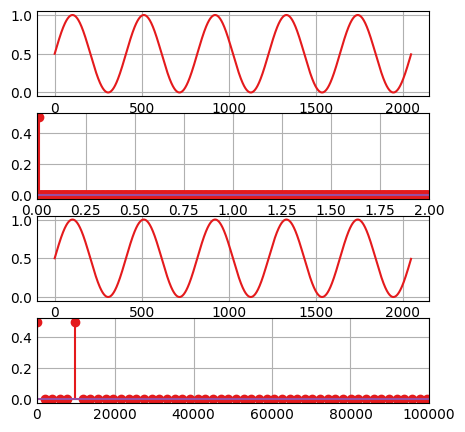

In [404]:
dut = Monotonic_SAR_ADC(N=16, Fs=4e6, Vref=1.0, Vcm=0.5, cap_mismatch_factor=0.01, seed=2)

M = 5
N = 2048
Fs = 4e6
fin = M*Fs/N
print(f'Input Frequency: {fin} Hz')

kk = np.arange(N)
t = np.linspace(0, N/Fs, N, endpoint=False)

sink = np.sin(2*np.pi*fin*t)
sink_p = 0.5*(sink + 1)
sink_n = 0.5*(-sink + 1)
output = dut.run(sink_p, sink_n, N)

# FFT
f_ax, mag_ax = dft(sink_p, N, Fs)
f_ax_dut, mag_ax_dut = dft(output, N, Fs)

sndr = calculate_sndr(output)
print(f'SNDR: {sndr}')
print(f'ENOB: {sndr2enob(sndr)}')

fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(4,4))
axs[0].plot(kk, sink_p)
axs[1].stem(f_ax, mag_ax)
axs[1].set_xlim(0, Fs / 2)
axs[2].plot(kk, output)
axs[3].stem(f_ax_dut, mag_ax_dut)
axs[3].set_xlim(0, Fs / 40)


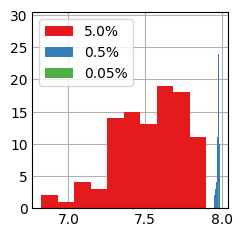

In [405]:

cap_mis = 5*10**-np.linspace(2, 4, 3)
for cap_iter, mis in enumerate(cap_mis):
	SAMPLES = 100
	mc_enob = np.zeros(SAMPLES)
	for i in range(SAMPLES):
		mc_dut = Monotonic_SAR_ADC(N=8, Fs=4e6, Vref=1.0, Vcm=0.5, cap_mismatch_factor=mis, seed=SAMPLES*cap_iter+i+np.random.randint(1e6))
		mc_output = mc_dut.run(sink_p, sink_n, N)
		mc_enob[i] = sndr2enob(calculate_sndr(mc_output))

	plt.hist(mc_enob, label=f'{mis*100}%')
plt.legend()